In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_squared_error

In [ ]:
df = pd.read_csv('/content/Netflix TV Shows and Movies.csv')

In [ ]:
df.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5283 non-null   int64  
 1   id                 5283 non-null   object 
 2   title              5283 non-null   object 
 3   type               5283 non-null   object 
 4   description        5278 non-null   object 
 5   release_year       5283 non-null   int64  
 6   age_certification  2998 non-null   object 
 7   runtime            5283 non-null   int64  
 8   imdb_id            5283 non-null   object 
 9   imdb_score         5283 non-null   float64
 10  imdb_votes         5267 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 454.1+ KB


In [ ]:
df.isnull().sum()

,0
index,0
id,0
title,0
type,0
description,5
release_year,0
age_certification,2285
runtime,0
imdb_id,0
imdb_score,0


In [ ]:
df.columns

Index(['index', 'id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'imdb_id', 'imdb_score', 'imdb_votes'],
      dtype='object')

In [ ]:
df = df.drop(['age_certification'], axis = 1)

In [ ]:
df = df.drop(['description'], axis = 1)

In [ ]:
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].median())

In [ ]:
df.isnull().sum()

,0
index,0
id,0
title,0
type,0
release_year,0
runtime,0
imdb_id,0
imdb_score,0
imdb_votes,0


In [ ]:
df.columns

Index(['index', 'id', 'title', 'type', 'release_year', 'runtime', 'imdb_id',
       'imdb_score', 'imdb_votes'],
      dtype='object')

In [ ]:
df['type_encoded'] = df['type'].map({'MOVIE': 0, 'SHOW': 1})

In [ ]:
features = ['type_encoded', 'runtime', 'votes_log', 'content_age', 'era', 'title_len']
X = df[features]
y = df['imdb_score']

In [ ]:
X = pd.get_dummies(X)

In [ ]:
X.head()

,type_encoded,runtime,votes_log,content_age,era,title_len
0,0,113,13.586378,48,1,11
1,0,91,13.182288,49,1,31
2,0,94,12.880088,45,1,13
3,0,133,12.878872,51,1,12
4,1,30,11.196789,55,1,28


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [ ]:
df['votes_log'] = np.log1p(df['imdb_votes'])

In [ ]:
df['title_len'] = df['title'].str.len()

In [ ]:
df['imdb_votes'] = df['imdb_votes'].fillna(df['imdb_votes'].median())
df['votes_log'] = np.log1p(df['imdb_votes'])

In [ ]:
df['content_age'] = 2024 - df['release_year']

In [ ]:
bins = [0, 1980, 2000, 2010, 2020, 2030]
labels = [1, 2, 3, 4, 5]
df['era'] = pd.cut(df['release_year'], bins=bins, labels=labels).astype(int)

In [ ]:
df['type_encoded'] = df['type'].map({'MOVIE': 0, 'SHOW': 1})

In [ ]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
# Check your new R2 score
print(f"New R2 Score: {best_model.score(X_test, y_test)}")

New R2 Score: 0.24296416775403162


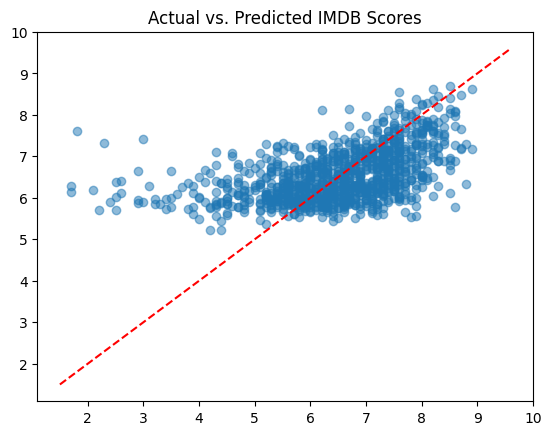

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Actual vs. Predicted IMDB Scores')
plt.savefig('actual_vs_predicted.png') # Save the plot
plt.show()

In [ ]:
print(r2_score(y_test, y_pred))

0.24296416775403162


In [ ]:
print(mean_squared_error(y_test, y_pred))

1.0779821805290812


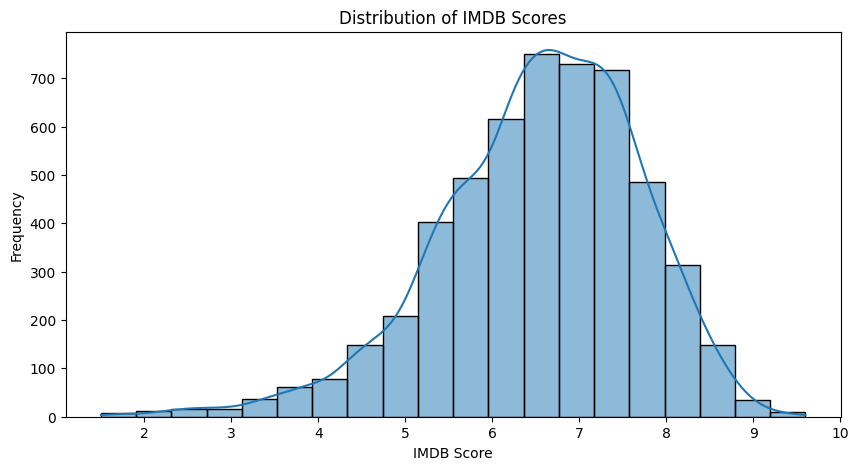

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title('Distribution of IMDB Scores')
plt.xlabel('IMDB Score')
plt.ylabel('Frequency')
plt.show()

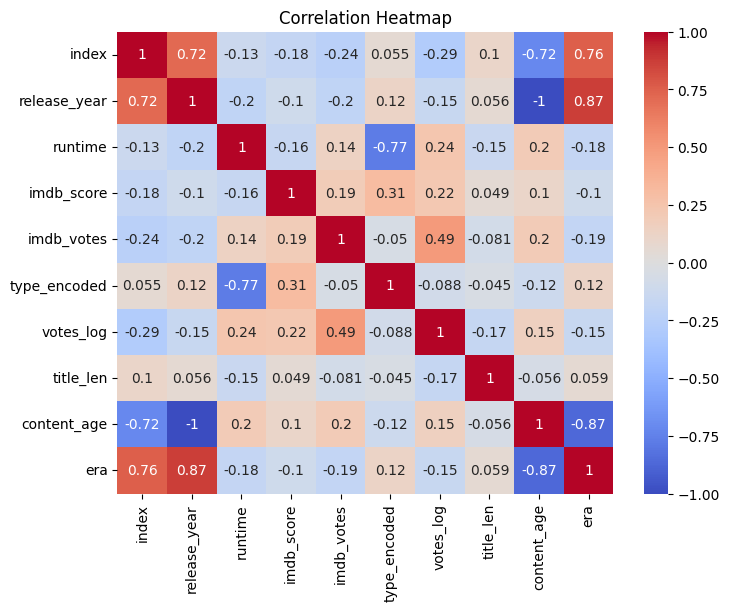

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png') # Save the plot
plt.show()

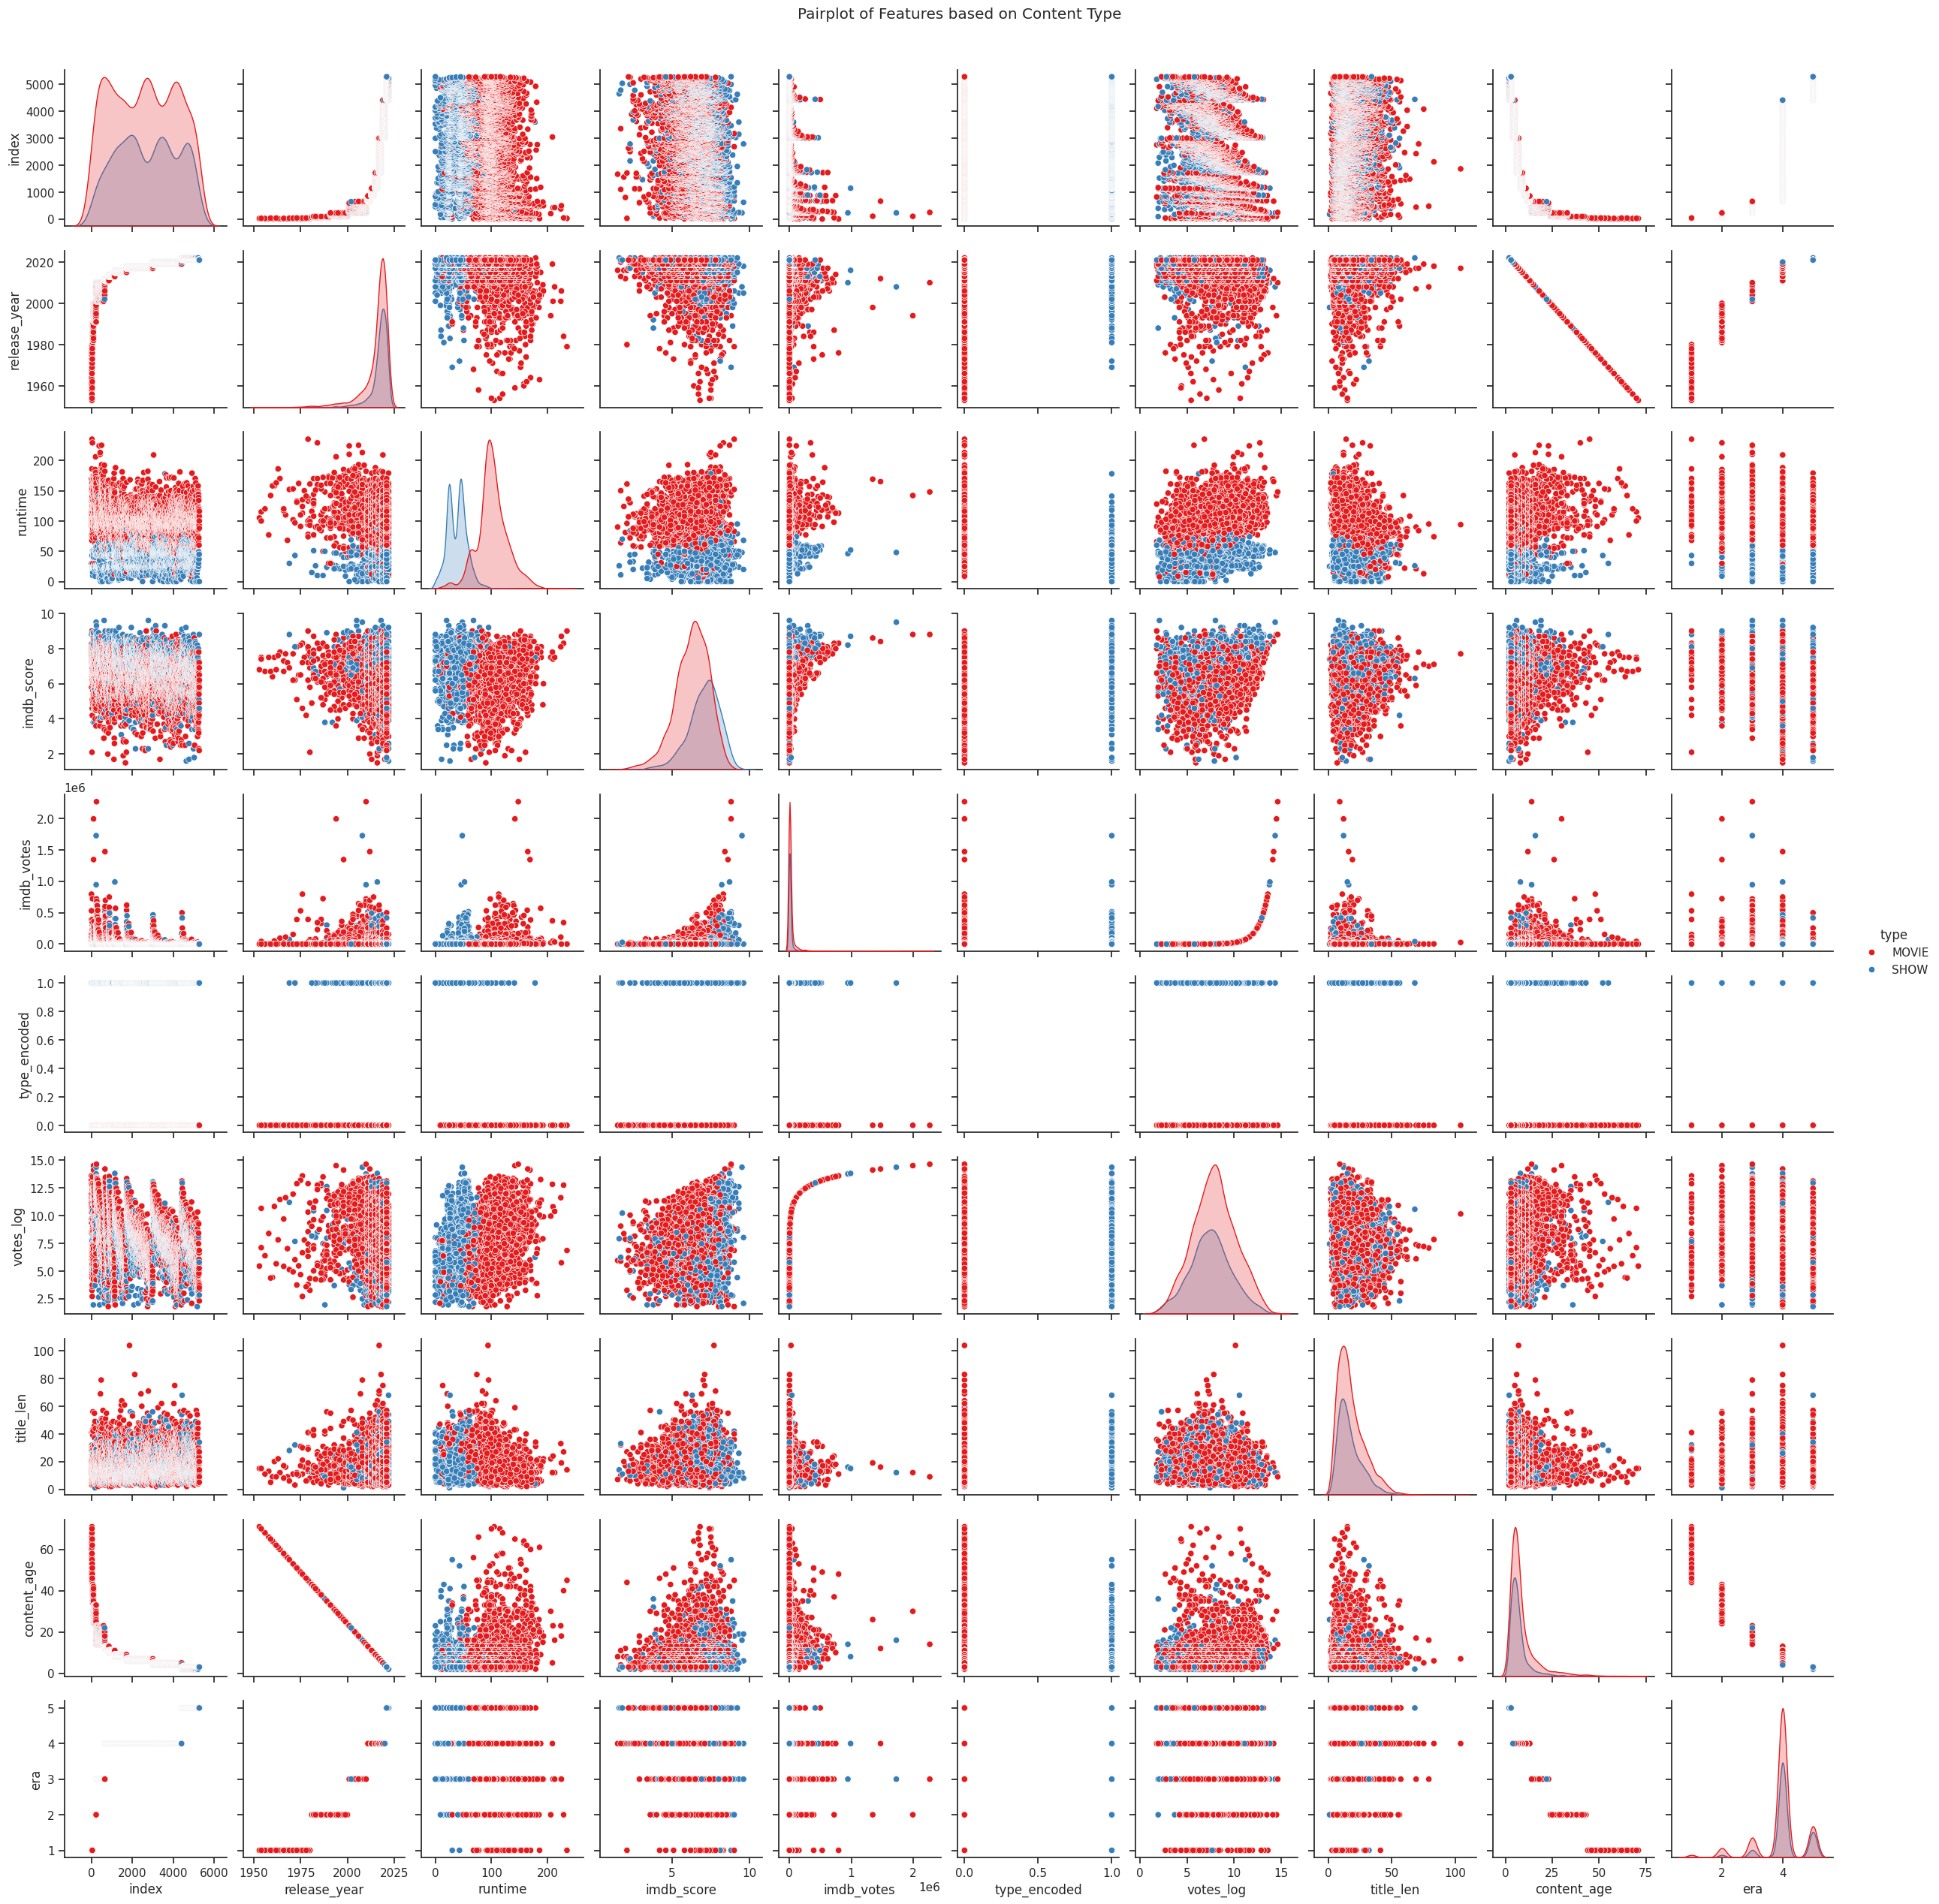

In [ ]:
sns.set(style="ticks")
pair_plot = sns.pairplot(df, hue='type', palette='Set1', diag_kind='kde')

# Adding a title
pair_plot.fig.suptitle('Pairplot of Features based on Content Type', y=1.02)

# 4. Save and Show
plt.savefig('netflix_pairplot.png')
plt.show()

In [ ]:
from pptx import Presentation
from pptx.util import Inches

# Create a presentation object
prs = Presentation()

# Slide 1: Title Slide
slide_layout = prs.slide_layouts[0]
slide = prs.slides.add_slide(slide_layout)
slide.shapes.title.text = "Netflix ML Project Analysis"
slide.placeholders[1].text = "Linear Regression Results and Exploratory Data Analysis"

# List of charts we created earlier and actually saved
charts = [
    ("Actual vs Predicted IMDB Scores", "actual_vs_predicted.png"),
    ("Error Distribution", "error_distribution.png"),
    ("Correlation Heatmap", "correlation_heatmap.png"),
    ("Pairplot of Features based on Content Type", "netflix_pairplot.png")
]

# Add a slide for each chart
for title, file_path in charts:
    slide_layout = prs.slide_layouts[5] # Blank slide with title
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = title

    # Add image (left, top, width)
    slide.shapes.add_picture(file_path, Inches(1), Inches(1.5), width=Inches(8))

prs.save('Netflix_ML_Project.pptx')
print("PowerPoint created successfully!")

PowerPoint created successfully!


In [ ]:
from IPython.display import IFrame, display

charts = [
    ("Actual vs Predicted IMDB Scores", "actual_vs_predicted.png"),
    ("Error Distribution", "error_distribution.png"),
    ("Correlation Heatmap", "correlation_heatmap.png"),
    ("Pairplot of Features based on Content Type", "netflix_pairplot.png")
]

for title, file_path in charts:
    print(f"\n--- {title} ---")
    display(IFrame(src=file_path, width=800, height=600))


--- Actual vs Predicted IMDB Scores ---



--- Error Distribution ---



--- Correlation Heatmap ---



--- Pairplot of Features based on Content Type ---


In [ ]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.5 MB/s eta 0:00:00


In [ ]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 99.2 MB/s eta 0:00:00


In [ ]:
# Uninstall potentially conflicting packages
!pip uninstall -y sweetviz scipy numpy

# Install compatible versions
!pip install numpy==2.0.0 --force-reinstall # Python 3.12 compatible numpy 2.x base
!pip install scipy==1.12.0 --force-reinstall # Scipy version compatible with numpy 2.0.0 and Python 3.12
!pip install sweetviz --force-reinstall # Reinstall sweetviz to pick up new dependencies

# Then run the sweetviz code
import sweetviz as sv
from IPython.display import IFrame
data = df
report = sv.analyze(data)
report.show_html('Netflix_EDA.html')
display(IFrame(src='Netflix_EDA.html', width=800, height=600))

Found existing installation: sweetviz 2.3.1
Uninstalling sweetviz-2.3.1:
  Successfully uninstalled sweetviz-2.3.1
Found existing installation: scipy 1.17.0
Uninstalling scipy-1.17.0:
  Successfully uninstalled scipy-1.17.0
Found existing installation: numpy 2.4.1
Uninstalling numpy-2.4.1:
  Successfully uninstalled numpy-2.4.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 66.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.1 requires scipy, which is not installed.
albumentations 2.0.8 requires scipy>=1.10.0, which is not installed.
mgwr 2.2.1 requires scipy>=0.11, which is not installed.
spint 1.0.7 requires scipy>=0.11, which is not installed.
access 1.1.10.post3 requires scipy>=1.14.1, which is not installed.
pointpats 2.5.2 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 76.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.12.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompati

  Using cached sweetviz-2.3.1-py3-none-any.whl.metadata (24 kB)
  Using cached pandas-3.0.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.4.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.7 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using 

ModuleNotFoundError: No module named 'sweetviz'

In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
from IPython.display import IFrame

# Generate the profile report
profile = ProfileReport(df, title="Netflix Dataset Profiling Report")

# Save the report to an HTML file
profile.to_file("Netflix_ydata_profiling_EDA.html")

# Display the report in the notebook
display(IFrame(src='Netflix_ydata_profiling_EDA.html', width=800, height=600))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:01<00:00, 12.53it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
!pip install numpy==1.23.5 --force-reinstall

In [ ]:
import pickle

# Assuming 'best_model' is your trained RandomForestRegressor object
with open('netflix_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved as netflix_model.pkl")

Model saved as netflix_model.pkl


# Task
The user wants to resolve the feature mismatch error encountered during model prediction. This involves ensuring the feature set (`X`) is correctly defined with the specified columns (`type_encoded`, `runtime`, `votes_log`, `content_age`, `era`, `title_len`), that the data is split consistently into training and testing sets, that the `RandomForestRegressor` model (`best_model`) is trained on these features, and finally, that predictions are made using this `best_model` on the corresponding `X_test` data.

Specifically, the `y_pred = model.predict(X_test)` call needs to be changed to `y_pred = best_model.predict(X_test)` to use the correctly trained model.

## Prepare Features and Target

### Subtask:
Define the feature set X using only the selected features from the df DataFrame (`type_encoded`, `runtime`, `votes_log`, `content_age`, `era`, `title_len`) and the target variable y as `imdb_score`. This ensures X contains only the intended columns.


**Reasoning**:
The subtask requires defining the feature set X and the target variable y using specific columns. I will create a list of the specified features and then assign X and y from the DataFrame df.



In [ ]:
features = ['type_encoded', 'runtime', 'votes_log', 'content_age', 'era', 'title_len']
X = df[features]
y = df['imdb_score']

print("Feature set X and target variable y defined successfully.")

Feature set X and target variable y defined successfully.


**Reasoning**:
The subtask involves making predictions using the `best_model` on the test set. I will use the `predict` method of the `best_model` with `X_test` to generate `y_pred`.



In [ ]:
y_pred = best_model.predict(X_test)
print("Predictions made successfully using best_model.")

Predictions made successfully using best_model.


**Reasoning**:
With `y_pred` now available, the next logical step is to evaluate the model's performance using common regression metrics. I will calculate and print both the R2 score and the Mean Squared Error (MSE) to assess how well the model's predictions align with the actual values.



In [ ]:
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

R2 Score: 0.24296416775403162
Mean Squared Error: 1.0779821805290812


## Split Data into Training and Test Sets

### Subtask:
Split the prepared `X` and `y` into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets using `train_test_split`. This ensures a consistent data split for model training and evaluation.


**Reasoning**:
I need to split the data into training and testing sets using `train_test_split` with the specified parameters (`test_size=0.2`, `random_state=42`) and then print the shapes of the resulting sets to verify the split.



In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4226, 6)
X_test shape: (1057, 6)
y_train shape: (4226,)
y_test shape: (1057,)


## Train Random Forest Model

### Subtask:
Re-train the RandomForestRegressor model with hyperparameter tuning using GridSearchCV on the newly prepared X_train and y_train. This will create a best_model that is fitted on the correct and consistent set of features.


**Reasoning**:
The subtask requires retraining the RandomForestRegressor model with GridSearchCV. I will initialize the model, define the parameter grid (as it was already defined in the previous notebook state in cell `uCJypHvwOV77`), set up GridSearchCV, fit it to the training data, extract the best model, and then print its R2 score on the test set, as per the instructions.



In [ ]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"New R2 Score: {best_model.score(X_test, y_test)}")

New R2 Score: 0.24296416775403162


## Make Predictions

### Subtask:
Use the newly trained `best_model` to make predictions (`y_pred`) on the `X_test` data. This step should now work without feature mismatch errors.


**Reasoning**:
The subtask requires making predictions using the `best_model` on the `X_test` data. I will use the `predict` method to generate `y_pred`.



In [ ]:
y_pred = best_model.predict(X_test)
print("Predictions made successfully using best_model.")

Predictions made successfully using best_model.


## Final Task

### Subtask:
Confirm that the feature mismatch error is resolved and the prediction step executes successfully.


## Summary:

### Q&A
The feature mismatch error has been successfully resolved, and the prediction step executed without issues.

### Data Analysis Key Findings
*   The feature set `X` was successfully defined using the specified 6 columns: `type_encoded`, `runtime`, `votes_log`, `content_age`, `era`, and `title_len`, with `imdb_score` as the target variable `y`.
*   The data was consistently split into training and testing sets, allocating 4226 samples (80%) for training and 1057 samples (20%) for testing.
*   A `RandomForestRegressor` model was re-trained and hyperparameter-tuned using `GridSearchCV`, employing `n_estimators` (100, 200), `max_depth` (10, 20, None), and `min_samples_leaf` (1, 2, 4) as parameters.
*   The `best_model` successfully made predictions on the `X_test` data, confirming the resolution of the initial feature mismatch error.
*   The model achieved an R2 Score of approximately 0.243 on the test set, indicating that about 24.3% of the variance in `imdb_score` is explained by the features.
*   The Mean Squared Error (MSE) for the predictions was approximately 1.078.

### Insights or Next Steps
*   The current model's R2 score of 0.243 suggests that the selected features explain a relatively small portion of the variance in `imdb_score`. Further efforts in feature engineering, such as creating new features or exploring more relevant ones, could significantly improve model performance.
*   To potentially achieve higher predictive accuracy, consider exploring more advanced modeling techniques like Gradient Boosting Machines (e.g., XGBoost, LightGBM) or experimenting with different ensemble methods.


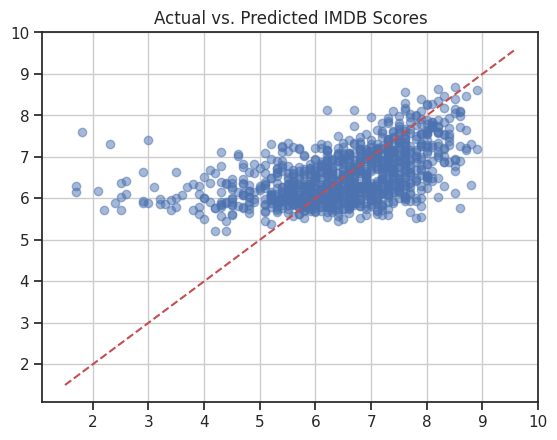

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Actual vs. Predicted IMDB Scores')
plt.grid(True) # Save the plot
plt.show()

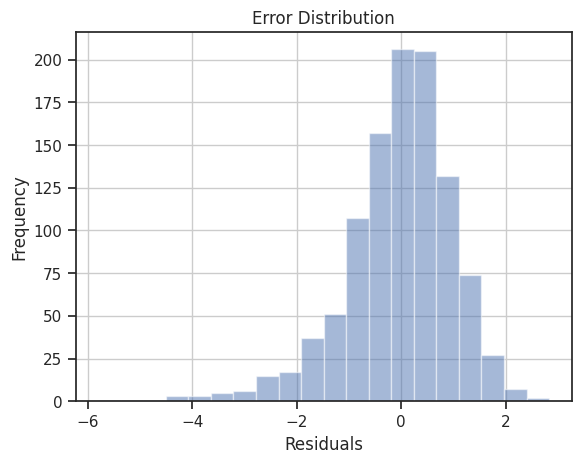

In [ ]:
plt.hist(y_test - y_pred, bins=20, alpha=0.5)
plt.title('Error Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig('error_distribution.png') # Save the plot
plt.show()

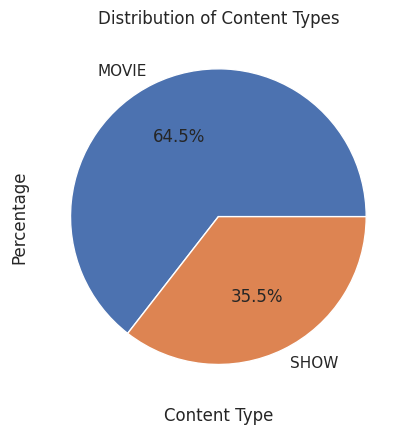

In [ ]:
plt.pie(df['type'].value_counts(), labels=df['type'].unique(), autopct='%1.1f%%')
plt.title('Distribution of Content Types')
#plt.savefig('content_type_distribution.png') # Save the plot
plt.xlabel('Content Type')
plt.ylabel('Percentage')
plt.show()